# Lab 5 + 6 — Augmentacja danych dla CNN + Rekurencyjne Sieci Neuronowe

**Wybrane Zagadnienia / Zaawansowane Metody Sztucznej Inteligencji · II stopień**

---

## Co zrobimy na tym podwójnym labie

**Część 1 — Lab 5: Augmentacja danych dla CNN**
1. **Dlaczego augmentacja?** — overfitting i mały dataset
2. **Galeria technik** — geometria, kolor, maskowanie, Mixup/CutMix
3. **ImageDataGenerator** — "on-the-fly" augmentacja w TensorFlow
4. **CIFAR-10 baseline** — CNN bez augmentacji (overfittuje)
5. **CIFAR-10 z augmentacją** — porównanie
6. **Hyperparameter tuning** — Random Search + KFold dla zakresów augmentacji

**Część 2 — Lab 6: RNN, LSTM, GRU**
1. **Po co RNN?** — dane sekwencyjne vs siatkowe (CNN)
2. **Architektura RNN** — pętla rekurencyjna, stan ukryty, BPTT
3. **Typy struktur** — one-to-many, many-to-one, seq2seq
4. **Vanishing/exploding gradient** — problem i rozwiązania
5. **LSTM** — bramki forget/input/output
6. **GRU** — uproszczona alternatywa
7. **DEMO LSTM** — predykcja sinusoidy z szumem (zadanie z PDF)

**Część 3 — Zadania samodzielne**
- Lab 5: CIFAR-10 z optymalizacją parametrów augmentacji
- Lab 6: PM-10 prediction dla Krakowa (Złoty Róg)

---

## 0. Setup

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers

tf.random.set_seed(42)
np.random.seed(42)

print(f"TensorFlow: {tf.__version__}")
print(f"GPU: {len(tf.config.list_physical_devices('GPU')) > 0}")
print("\nTip: na CPU CIFAR uczy sie ~2-3 min, LSTM ~30s. Na GPU 10x szybciej.")

TensorFlow: 2.20.0
GPU: False

Tip: na CPU CIFAR uczy sie ~2-3 min, LSTM ~30s. Na GPU 10x szybciej.


---

# CZĘŚĆ 1 — Lab 5: Augmentacja danych dla CNN

## 1.1. Dlaczego augmentacja?

**Problem:** CNN potrzebuje **dużo** danych żeby się dobrze generalizować. Jeśli masz 1000 zdjęć kota i 1000 psa — model zapamiętuje **te konkretne** zdjęcia (overfitting), a nie *czym jest kot*.

**Rozwiązanie:** sztucznie zwiększamy dataset przez **transformacje** istniejących zdjęć. Kot obrócony o 10° to nadal kot. Kot z większą jasnością to nadal kot. Sieć uczy się **inwariantności**.

### Trzy główne korzyści

| Korzyść | Dlaczego |
|---------|----------|
| **Zapobieganie overfittingowi** | Sieć nie widzi nigdy dwa razy tego samego zdjęcia |
| **Symulowanie rzeczywistych wariacji** | W realnym świecie kot może być pod różnym kątem |
| **Zwiększanie datasetu "za darmo"** | Bez zbierania nowych danych |

### Dwie praktyki

- **On-the-fly** — augmentacja w czasie treningu, każda epoka = nowe wersje (popularne, oszczędza dysk)
- **Pre-processing** — generujemy zmienione zdjęcia z wyprzedzeniem i zapisujemy (rzadziej)

## 1.2. Galeria technik augmentacji

Pokażemy każdą technikę na jednym obrazku z MNIST/CIFAR, żeby było widać efekt.

170498071/170498071 ━━━━━━━━━━━━━━━━━━━━ 8s 0us/step
x_cifar_train: (50000, 32, 32, 3)  (50k obrazow 32x32x3)
y_cifar_train: (50000, 1)

Obraz testowy: pies


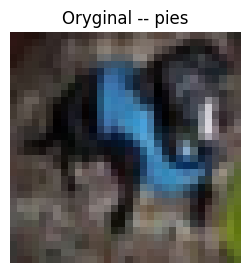

In [2]:
# Wczytaj CIFAR-10 (10 klas obrazow 32x32 RGB)
(x_cifar_train, y_cifar_train), (x_cifar_test, y_cifar_test) = keras.datasets.cifar10.load_data()

class_names = ['samolot', 'auto', 'ptak', 'kot', 'jelen',
               'pies', 'zaba', 'kon', 'statek', 'ciezarowka']

print(f"x_cifar_train: {x_cifar_train.shape}  (50k obrazow 32x32x3)")
print(f"y_cifar_train: {y_cifar_train.shape}")

# Wybierzmy jeden obrazek -- np. psa
idx = np.where(y_cifar_train.flatten() == 5)[0][0]  # pies
obraz = x_cifar_train[idx]
print(f"\nObraz testowy: {class_names[y_cifar_train[idx][0]]}")

plt.figure(figsize=(3, 3))
plt.imshow(obraz)
plt.title(f"Oryginal -- {class_names[y_cifar_train[idx][0]]}")
plt.axis('off')
plt.show()

### Grupa A: Transformacje geometryczne

**Obrót, odbicie, skalowanie, przesunięcie, ścinanie.** Zmieniają **pozycję pikseli** ale nie ich wartości.

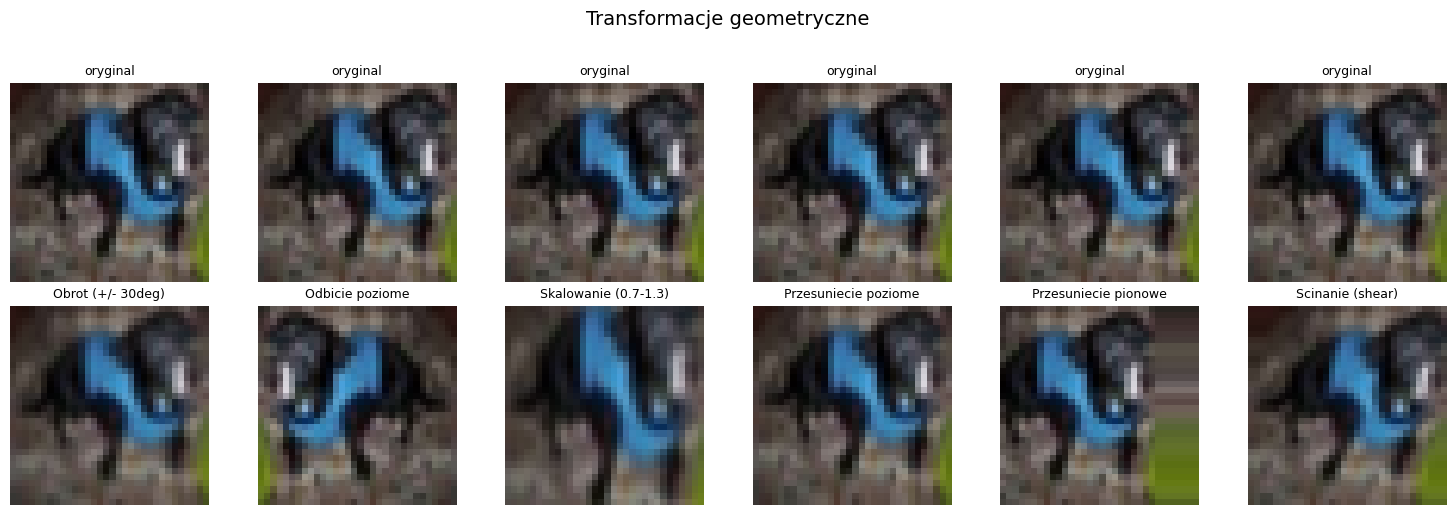

In [3]:
# Galeria transformacji geometrycznych
from tensorflow.keras.preprocessing.image import ImageDataGenerator

obraz_batch = np.expand_dims(obraz, 0)  # (1, 32, 32, 3) -- IDG wymaga batcha

transforms_geo = {
    "Obrot (+/- 30deg)":   ImageDataGenerator(rotation_range=30),
    "Odbicie poziome":     ImageDataGenerator(horizontal_flip=True),
    "Skalowanie (0.7-1.3)":ImageDataGenerator(zoom_range=0.3),
    "Przesuniecie poziome":ImageDataGenerator(width_shift_range=0.2),
    "Przesuniecie pionowe":ImageDataGenerator(height_shift_range=0.2),
    "Scinanie (shear)":    ImageDataGenerator(shear_range=20),
}

fig, axes = plt.subplots(2, 6, figsize=(15, 5))
for col, (name, gen) in enumerate(transforms_geo.items()):
    axes[0, col].imshow(obraz)
    axes[0, col].set_title("oryginal", fontsize=9)
    axes[0, col].axis('off')
    aug_iter = gen.flow(obraz_batch, batch_size=1, seed=col)
    aug = next(aug_iter)[0].astype('uint8')
    axes[1, col].imshow(aug)
    axes[1, col].set_title(name, fontsize=9)
    axes[1, col].axis('off')
plt.suptitle("Transformacje geometryczne", fontsize=14, y=1.02)
plt.tight_layout()
plt.show()

### Grupa B: Modyfikacje intensywności i kolorów

**Jasność, kontrast, nasycenie, szum.** Zmieniają **wartości pikseli** ale nie ich pozycje.

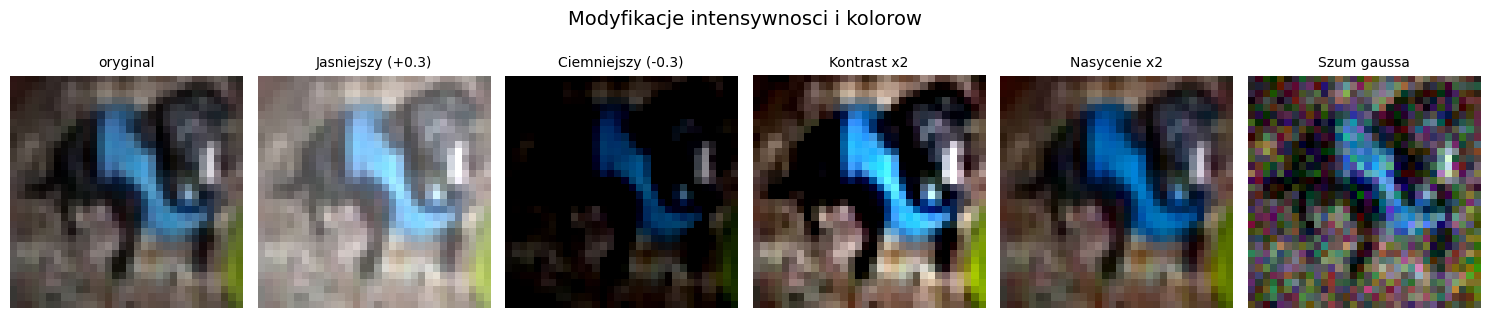

In [4]:
# Reczne implementacje (IDG nie ma wszystkich tych opcji)
from tensorflow.image import (adjust_brightness, adjust_contrast,
                              adjust_saturation)

obraz_f = obraz.astype('float32') / 255.0

transforms_color = {
    "Jasniejszy (+0.3)": adjust_brightness(obraz_f, 0.3).numpy(),
    "Ciemniejszy (-0.3)": adjust_brightness(obraz_f, -0.3).numpy(),
    "Kontrast x2":        adjust_contrast(obraz_f, 2.0).numpy(),
    "Nasycenie x2":       adjust_saturation(obraz_f, 2.0).numpy(),
    "Szum gaussa":        np.clip(obraz_f + np.random.normal(0, 0.1, obraz_f.shape), 0, 1),
}

fig, axes = plt.subplots(1, 6, figsize=(15, 3))
axes[0].imshow(obraz)
axes[0].set_title("oryginal", fontsize=10)
axes[0].axis('off')
for col, (name, aug) in enumerate(transforms_color.items(), 1):
    axes[col].imshow(np.clip(aug, 0, 1))
    axes[col].set_title(name, fontsize=10)
    axes[col].axis('off')
plt.suptitle("Modyfikacje intensywnosci i kolorow", fontsize=14, y=1.05)
plt.tight_layout()
plt.show()

### Grupa C: Cięcie i maskowanie (Random Erasing, Mixup, CutMix)

**Zaawansowane techniki 2020+.** Wymuszają na sieci, żeby nie patrzyła tylko na jeden fragment obrazu.

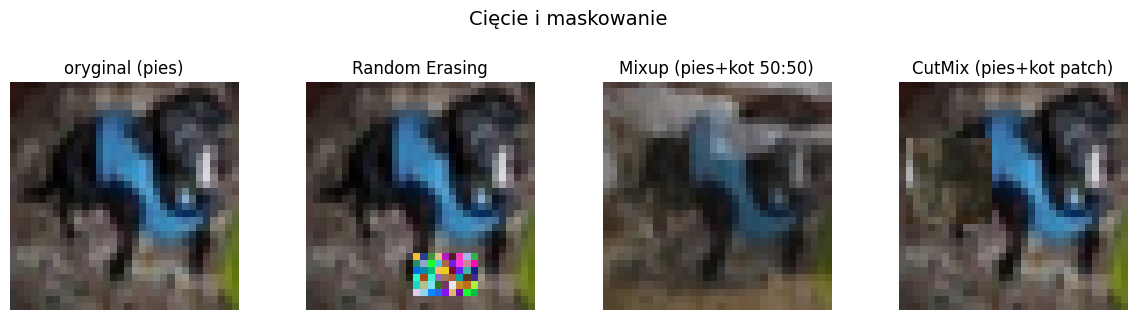

In [5]:
def random_erasing(img, max_size=0.3):
    """Losowe wymazanie kawalka obrazu."""
    img = img.copy()
    h, w = img.shape[:2]
    sh = int(h * np.random.uniform(0.1, max_size))
    sw = int(w * np.random.uniform(0.1, max_size))
    y = np.random.randint(0, h - sh)
    x = np.random.randint(0, w - sw)
    img[y:y+sh, x:x+sw] = np.random.randint(0, 255, (sh, sw, 3))
    return img

def mixup(img1, img2, alpha=0.5):
    """Liniowa interpolacja dwoch obrazow."""
    return (alpha * img1 + (1 - alpha) * img2).astype('uint8')

def cutmix(img1, img2, frac=0.4):
    """Wycinamy kawalek img2 i wklejamy do img1."""
    img = img1.copy()
    h, w = img.shape[:2]
    sh = int(h * frac); sw = int(w * frac)
    y = np.random.randint(0, h - sh); x = np.random.randint(0, w - sw)
    img[y:y+sh, x:x+sw] = img2[y:y+sh, x:x+sw]
    return img

# Drugi obraz -- kot
idx2 = np.where(y_cifar_train.flatten() == 3)[0][0]
obraz2 = x_cifar_train[idx2]

fig, axes = plt.subplots(1, 4, figsize=(12, 3))
axes[0].imshow(obraz); axes[0].set_title("oryginal (pies)"); axes[0].axis('off')
axes[1].imshow(random_erasing(obraz)); axes[1].set_title("Random Erasing"); axes[1].axis('off')
axes[2].imshow(mixup(obraz, obraz2)); axes[2].set_title("Mixup (pies+kot 50:50)"); axes[2].axis('off')
axes[3].imshow(cutmix(obraz, obraz2)); axes[3].set_title("CutMix (pies+kot patch)"); axes[3].axis('off')
plt.suptitle("Cięcie i maskowanie", fontsize=14, y=1.05)
plt.tight_layout()
plt.show()

---

## 1.3. ImageDataGenerator — augmentacja w treningu

`ImageDataGenerator` to klasa Keras, która **w czasie rzeczywistym** generuje zmienione wersje obrazów dla każdej epoki.

**Kluczowy zysk:** sieć w 100 epok widzi **100 różnych** wersji każdego obrazu. Bez augmentacji widzi ten sam 100 razy.

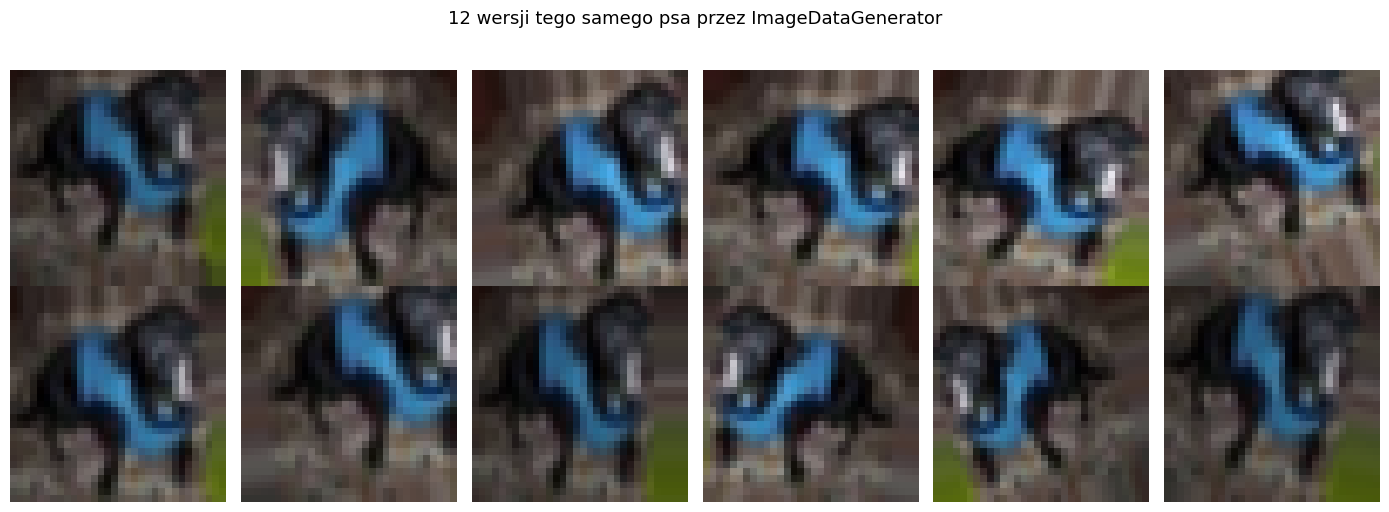

Kazda komorka to ten sam piksel, ale po roznych transformacjach.
To dziala na BIEZACO podczas .fit() -- nie zapisujemy zmodyfikowanych obrazow.


In [6]:
# Demonstracja: 12 wersji tego samego psa z augmentacja "all-in"
datagen = ImageDataGenerator(
    rotation_range=20,
    width_shift_range=0.1,
    height_shift_range=0.1,
    zoom_range=0.15,
    horizontal_flip=True,
    brightness_range=(0.7, 1.3),
)

aug_iter = datagen.flow(np.expand_dims(obraz, 0), batch_size=1)

fig, axes = plt.subplots(2, 6, figsize=(14, 5))
for ax in axes.flat:
    aug = next(aug_iter)[0].astype('uint8')
    ax.imshow(aug)
    ax.axis('off')
plt.suptitle("12 wersji tego samego psa przez ImageDataGenerator", fontsize=13, y=1.02)
plt.tight_layout()
plt.show()

print("Kazda komorka to ten sam piksel, ale po roznych transformacjach.")
print("To dziala na BIEZACO podczas .fit() -- nie zapisujemy zmodyfikowanych obrazow.")

---

## 1.4. Baseline CNN — CIFAR-10 BEZ augmentacji

Najpierw trenujemy **bez** augmentacji. Zobaczymy wyraźny overfitting.

**Setup zadania (z PDF):**
- Ograniczamy CIFAR-10 do **4 klas i 2000 zdjęć** (szybsza optymalizacja)
- Normalizacja (mean/std)
- One-hot encoding etykiet

In [7]:
# Ograniczamy do 4 klas i 2000 zdjec
KLASY = [3, 5, 6, 7]  # kot, pies, zaba, kon
N_CLASSES = len(KLASY)
N_TRAIN = 2000

# Filtruj train
mask_train = np.isin(y_cifar_train.flatten(), KLASY)
x_tr = x_cifar_train[mask_train][:N_TRAIN]
y_tr = y_cifar_train[mask_train][:N_TRAIN]

# Filtruj test
mask_test = np.isin(y_cifar_test.flatten(), KLASY)
x_te = x_cifar_test[mask_test]
y_te = y_cifar_test[mask_test]

# Przemapuj etykiety na 0..3
label_map = {orig: new for new, orig in enumerate(KLASY)}
y_tr = np.vectorize(label_map.get)(y_tr.flatten())
y_te = np.vectorize(label_map.get)(y_te.flatten())

# Normalizacja (mean/std) -- standard ML practice
x_tr_f = x_tr.astype('float32')
x_te_f = x_te.astype('float32')
mean = x_tr_f.mean(axis=(0, 1, 2))
std = x_tr_f.std(axis=(0, 1, 2))
x_tr_norm = (x_tr_f - mean) / std
x_te_norm = (x_te_f - mean) / std

# One-hot
y_tr_oh = keras.utils.to_categorical(y_tr, N_CLASSES)
y_te_oh = keras.utils.to_categorical(y_te, N_CLASSES)

print(f"Klasy: {[class_names[k] for k in KLASY]}")
print(f"x_tr: {x_tr_norm.shape}, y_tr_oh: {y_tr_oh.shape}")
print(f"x_te: {x_te_norm.shape}, y_te_oh: {y_te_oh.shape}")

Klasy: ['kot', 'pies', 'zaba', 'kon']
x_tr: (2000, 32, 32, 3), y_tr_oh: (2000, 4)
x_te: (4000, 32, 32, 3), y_te_oh: (4000, 4)


In [8]:
def cnn_model(num_filters=32, dropout_conv=0.0, dropout_dense=0.5):
    """CNN architecture z PDF -- 3 bloki conv + dense + softmax.
    Mniejsza wersja niz w PDF zeby trening byl szybki.
    """
    model = keras.Sequential([
        layers.Conv2D(num_filters, 3, activation='relu', padding='same', input_shape=(32, 32, 3)),
        layers.BatchNormalization(),
        layers.Conv2D(num_filters, 3, activation='relu', padding='same'),
        layers.BatchNormalization(),
        layers.MaxPooling2D(2),
        layers.Dropout(dropout_conv),

        layers.Conv2D(2*num_filters, 3, activation='relu', padding='same'),
        layers.BatchNormalization(),
        layers.Conv2D(2*num_filters, 3, activation='relu', padding='same'),
        layers.BatchNormalization(),
        layers.MaxPooling2D(2),
        layers.Dropout(dropout_conv),

        layers.Flatten(),
        layers.Dense(128, activation='relu'),
        layers.BatchNormalization(),
        layers.Dropout(dropout_dense),
        layers.Dense(N_CLASSES, activation='softmax')
    ])
    model.compile(optimizer=keras.optimizers.Adam(1e-3),
                  loss='categorical_crossentropy',
                  metrics=['accuracy'])
    return model

# Baseline -- bez augmentacji
print("=== Baseline CNN (BEZ augmentacji) ===")
tf.random.set_seed(42)
model_baseline = cnn_model()
hist_baseline = model_baseline.fit(
    x_tr_norm, y_tr_oh,
    epochs=15, batch_size=64,
    validation_split=0.2,
    verbose=2
)
test_loss_b, test_acc_b = model_baseline.evaluate(x_te_norm, y_te_oh, verbose=0)
print(f"\nTest accuracy BEZ augmentacji: {test_acc_b:.4f}")

=== Baseline CNN (BEZ augmentacji) ===
Epoch 1/15


/Users/macbook/miniconda3/lib/python3.12/site-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


25/25 - 3s - 138ms/step - accuracy: 0.4288 - loss: 1.7438 - val_accuracy: 0.2850 - val_loss: 1.3892
Epoch 2/15
25/25 - 1s - 59ms/step - accuracy: 0.5806 - loss: 1.1004 - val_accuracy: 0.2575 - val_loss: 1.7013
Epoch 3/15
25/25 - 2s - 65ms/step - accuracy: 0.6787 - loss: 0.8693 - val_accuracy: 0.2550 - val_loss: 1.8743
Epoch 4/15
25/25 - 2s - 65ms/step - accuracy: 0.7625 - loss: 0.6095 - val_accuracy: 0.2550 - val_loss: 1.9073
Epoch 5/15
25/25 - 2s - 71ms/step - accuracy: 0.8256 - loss: 0.4451 - val_accuracy: 0.2525 - val_loss: 2.2857
Epoch 6/15
25/25 - 2s - 77ms/step - accuracy: 0.8725 - loss: 0.3357 - val_accuracy: 0.2675 - val_loss: 2.0526
Epoch 7/15
25/25 - 2s - 71ms/step - accuracy: 0.9100 - loss: 0.2690 - val_accuracy: 0.2575 - val_loss: 1.9631
Epoch 8/15
25/25 - 2s - 72ms/step - accuracy: 0.9469 - loss: 0.1805 - val_accuracy: 0.2925 - val_loss: 1.7351
Epoch 9/15
25/25 - 2s - 69ms/step - accuracy: 0.9494 - loss: 0.1589 - val_accuracy: 0.3600 - val_loss: 1.4899
Epoch 10/15
25/25 - 

## 1.5. CNN Z augmentacją

In [9]:
# Trening Z augmentacja przez ImageDataGenerator
print("=== CNN Z augmentacja ===")

datagen_train = ImageDataGenerator(
    rotation_range=15,
    width_shift_range=0.1,
    height_shift_range=0.1,
    zoom_range=0.1,
    horizontal_flip=True,
)

# Podzial na train/val przed generatorem
split = int(0.8 * len(x_tr_norm))
x_t, x_v = x_tr_norm[:split], x_tr_norm[split:]
y_t, y_v = y_tr_oh[:split], y_tr_oh[split:]

tf.random.set_seed(42)
model_aug = cnn_model()
hist_aug = model_aug.fit(
    datagen_train.flow(x_t, y_t, batch_size=64),
    epochs=15,
    validation_data=(x_v, y_v),
    verbose=2
)
test_loss_a, test_acc_a = model_aug.evaluate(x_te_norm, y_te_oh, verbose=0)
print(f"\nTest accuracy Z augmentacja: {test_acc_a:.4f}")

=== CNN Z augmentacja ===
Epoch 1/15
25/25 - 4s - 146ms/step - accuracy: 0.4019 - loss: 1.9114 - val_accuracy: 0.4225 - val_loss: 1.2745
Epoch 2/15
25/25 - 2s - 79ms/step - accuracy: 0.4719 - loss: 1.4599 - val_accuracy: 0.3525 - val_loss: 1.3129
Epoch 3/15
25/25 - 2s - 83ms/step - accuracy: 0.5163 - loss: 1.3098 - val_accuracy: 0.3000 - val_loss: 1.4244
Epoch 4/15
25/25 - 2s - 79ms/step - accuracy: 0.5519 - loss: 1.2137 - val_accuracy: 0.2950 - val_loss: 1.4208
Epoch 5/15
25/25 - 2s - 73ms/step - accuracy: 0.5719 - loss: 1.0964 - val_accuracy: 0.3175 - val_loss: 1.4485
Epoch 6/15
25/25 - 2s - 72ms/step - accuracy: 0.6012 - loss: 1.0585 - val_accuracy: 0.3025 - val_loss: 1.4667
Epoch 7/15
25/25 - 2s - 74ms/step - accuracy: 0.6156 - loss: 1.0128 - val_accuracy: 0.4100 - val_loss: 1.3103
Epoch 8/15
25/25 - 2s - 84ms/step - accuracy: 0.6219 - loss: 0.9607 - val_accuracy: 0.4900 - val_loss: 1.1750
Epoch 9/15
25/25 - 2s - 77ms/step - accuracy: 0.6444 - loss: 0.8796 - val_accuracy: 0.5250 - 

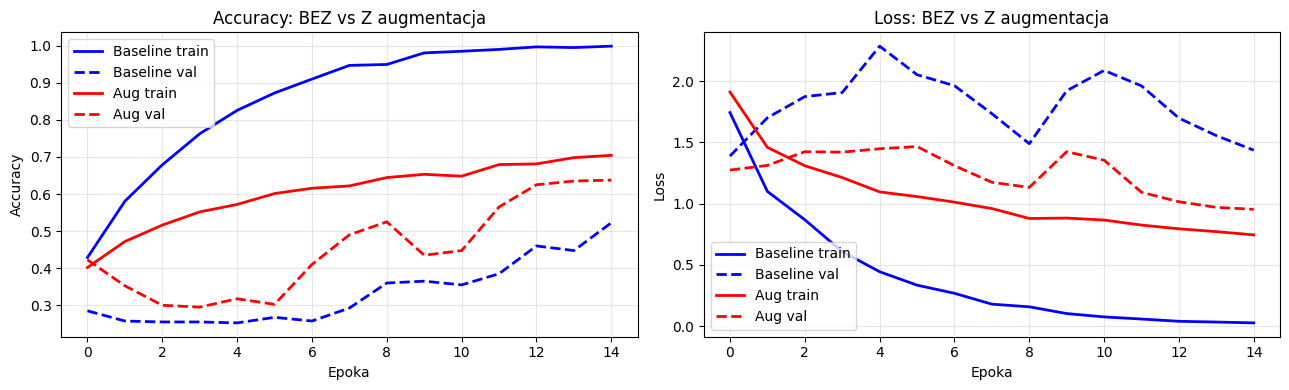


=== WYNIKI ===
Baseline (bez aug): test acc = 0.5310
Z augmentacja:      test acc = 0.6050
Roznica:            +7.40%

Obserwacja: baseline OVERFITTUJE -- train acc rosnie do 100%, val acc stoi.
Z augmentacja: train acc nizsze, ale val/test acc wyzsze -> lepsza generalizacja.


In [10]:
# Porownanie krzywych uczenia
fig, axes = plt.subplots(1, 2, figsize=(13, 4))

axes[0].plot(hist_baseline.history['accuracy'], 'b-', label='Baseline train', linewidth=2)
axes[0].plot(hist_baseline.history['val_accuracy'], 'b--', label='Baseline val', linewidth=2)
axes[0].plot(hist_aug.history['accuracy'], 'r-', label='Aug train', linewidth=2)
axes[0].plot(hist_aug.history['val_accuracy'], 'r--', label='Aug val', linewidth=2)
axes[0].set_xlabel('Epoka')
axes[0].set_ylabel('Accuracy')
axes[0].set_title('Accuracy: BEZ vs Z augmentacja')
axes[0].legend()
axes[0].grid(alpha=0.3)

axes[1].plot(hist_baseline.history['loss'], 'b-', label='Baseline train', linewidth=2)
axes[1].plot(hist_baseline.history['val_loss'], 'b--', label='Baseline val', linewidth=2)
axes[1].plot(hist_aug.history['loss'], 'r-', label='Aug train', linewidth=2)
axes[1].plot(hist_aug.history['val_loss'], 'r--', label='Aug val', linewidth=2)
axes[1].set_xlabel('Epoka')
axes[1].set_ylabel('Loss')
axes[1].set_title('Loss: BEZ vs Z augmentacja')
axes[1].legend()
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.show()

print(f"\n=== WYNIKI ===")
print(f"Baseline (bez aug): test acc = {test_acc_b:.4f}")
print(f"Z augmentacja:      test acc = {test_acc_a:.4f}")
print(f"Roznica:            {(test_acc_a - test_acc_b)*100:+.2f}%")
print("\nObserwacja: baseline OVERFITTUJE -- train acc rosnie do 100%, val acc stoi.")
print("Z augmentacja: train acc nizsze, ale val/test acc wyzsze -> lepsza generalizacja.")

---

## 1.6. Hyperparameter tuning — Random Search

Z PDF: *"Potraktuj zakresy transformacji geometrycznych jako hiperparametry modelu i przeprowadź ich dobór (np. przy użyciu podejścia Random Search). Jako kryterium optymalizacji wykorzystaj dokładność uzyskaną w wyniku kroswalidacji k-fold."*

**Mini-demo:** sprawdzimy 4 losowe konfiguracje augmentacji i wybierzemy najlepszą po prostym holdout (zamiast pełnego KFold, żeby zmieścić się czasowo).

In [11]:
import time

# Przestrzen hiperparametrow
search_space = {
    'rotation_range':     [0, 10, 20, 30],
    'width_shift_range':  [0.0, 0.1, 0.2],
    'zoom_range':         [0.0, 0.1, 0.2],
}

def sample_config():
    return {k: np.random.choice(v) for k, v in search_space.items()}

N_TRIALS = 4  # zwieksz do 10+ dla rzetelnej optymalizacji

results = []
for trial in range(N_TRIALS):
    config = sample_config()
    t0 = time.time()
    print(f"\nTrial {trial+1}/{N_TRIALS}: {dict(config)}")
    
    datagen = ImageDataGenerator(
        rotation_range=int(config['rotation_range']),
        width_shift_range=float(config['width_shift_range']),
        zoom_range=float(config['zoom_range']),
        horizontal_flip=True,
    )
    
    tf.random.set_seed(42)
    model = cnn_model()
    hist = model.fit(
        datagen.flow(x_t, y_t, batch_size=64),
        epochs=8, validation_data=(x_v, y_v), verbose=0
    )
    val_acc = hist.history['val_accuracy'][-1]
    elapsed = time.time() - t0
    results.append({'config': dict(config), 'val_acc': val_acc, 'time': elapsed})
    print(f"  val_acc = {val_acc:.4f}  ({elapsed:.1f}s)")

# Najlepszy
best = max(results, key=lambda r: r['val_acc'])
print(f"\n=== Najlepsza konfiguracja ===")
print(f"Config: {best['config']}")
print(f"Val accuracy: {best['val_acc']:.4f}")


Trial 1/4: {'rotation_range': 0, 'width_shift_range': 0.0, 'zoom_range': 0.1}
  val_acc = 0.3500  (17.2s)

Trial 2/4: {'rotation_range': 30, 'width_shift_range': 0.0, 'zoom_range': 0.1}
  val_acc = 0.3825  (16.7s)

Trial 3/4: {'rotation_range': 30, 'width_shift_range': 0.0, 'zoom_range': 0.2}
  val_acc = 0.5450  (16.6s)

Trial 4/4: {'rotation_range': 30, 'width_shift_range': 0.1, 'zoom_range': 0.2}
  val_acc = 0.4125  (16.7s)

=== Najlepsza konfiguracja ===
Config: {'rotation_range': 30, 'width_shift_range': 0.0, 'zoom_range': 0.2}
Val accuracy: 0.5450


---

# CZĘŚĆ 2 — Lab 6: Rekurencyjne Sieci Neuronowe (RNN)

## 2.1. Most: dlaczego CNN nie wystarczy?

**CNN (Lab 4-5)** ekstrahuje cechy z **siatek** o stałym rozmiarze (obrazy 32x32, 224x224, ...). 

Co jeśli dane są **sekwencjami** o zmiennej długości?
- **Tekst:** "Lubię koty" (3 słowa) vs "Lubię koty i psy" (5 słów)
- **Szeregi czasowe:** kursy walut, temperatury, pomiary IoT
- **Audio:** sygnał o długości 1s lub 10s
- **DNA:** sekwencje nukleotydów

**CNN ignoruje kolejność.** Dla sekwencji potrzebujemy sieci, która **pamięta** poprzednie elementy.

## 2.2. Architektura RNN

**Kluczowa idea:** **pętla rekurencyjna**. Sieć ma **stan ukryty** $a_t$ który aktualizuje się przy każdym kroku czasowym.

$$a_t = g_1(W_{aa} a_{t-1} + W_{ax} x_t + b_a)$$
$$y_t = g_2(W_{ya} a_t + b_y)$$

**Czytaj to jako:** "nowy stan = funkcja(stary stan, nowe wejście)".

### Kluczowe cechy RNN

| Cecha | Co znaczy |
|-------|-----------|
| **Pamięć wewnętrzna** | Stan ukryty zapamiętuje kontekst |
| **Przetwarzanie sekwencyjne** | Kolejność elementów ma znaczenie |
| **Współdzielone wagi** | Te same $W_{aa}, W_{ax}, W_{ya}$ dla każdego kroku |
| **Dynamiczne** | Działa na sekwencjach o dowolnej długości |

**Trening: BPTT** — Backpropagation Through Time. Rozwijasz sieć w czasie (jak T kopii MLP) i propagujesz gradient wstecz przez wszystkie kroki.

## 2.3. Typy struktur RNN

| Typ | Schemat | Przykład zastosowania |
|-----|---------|----------------------|
| **One-to-one** ($T_x=T_y=1$) | x → y | Klasyczna klasyfikacja (= MLP) |
| **One-to-many** ($T_x=1, T_y>1$) | x → y₁, y₂, ... | Generowanie muzyki, captioning obrazów |
| **Many-to-one** ($T_x>1, T_y=1$) | x₁, x₂, ... → y | Analiza sentymentu, klasyfikacja sekwencji |
| **Many-to-many (equal)** ($T_x=T_y$) | x_t → y_t | Tagowanie sekwencji (NER) |
| **Many-to-many (seq2seq)** ($T_x ≠ T_y$) | x_1..T_x → y_1..T_y | Tłumaczenie maszynowe |

## 2.4. Problem: Vanishing i Exploding Gradient

W BPTT mnożymy gradienty przez wiele kroków czasowych. Konsekwencje:

### Vanishing gradient
- **Przyczyna:** pochodne sigmoidy/tanh są < 1. Mnożenie ich wielokrotnie → wartość zbliża się do 0.
- **Skutek:** sieć **zapomina** informacje z początku sekwencji.
- **Matematyka:** jeśli $|\partial a_t / \partial a_{t-1}| < 1$, to $\prod$ → 0.

### Exploding gradient
- **Przyczyna:** wagi duże, pochodne >> 1. Mnożenie → wybuch.
- **Skutek:** wagi NaN, model nie zbiega.

### Rozwiązania

1. **Gradient Clipping** — ucinamy gradient powyżej progu (`clipnorm=1.0` w Keras)
2. **Bramki — LSTM / GRU** — kontrolowany przepływ informacji
3. **Regularyzacja/normalizacja** — L2, BatchNorm, LayerNorm

## 2.5. LSTM — Long Short-Term Memory

**LSTM** rozwiązuje vanishing gradient przez **komórkę pamięci** $C_t$ i **bramki** (gates).

### Trzy bramki

1. **Forget gate** $F_t$ — *co zapomnieć z pamięci?*
2. **Input gate** $I_t$ — *co nowego dodać do pamięci?*
3. **Output gate** $O_t$ — *co wypuścić jako wyjście?*

### Równania (6 kroków)

$$F_t = \sigma(W_f \cdot [h_{t-1}, x_t] + b_f) \quad \text{forget gate}$$
$$I_t = \sigma(W_i \cdot [h_{t-1}, x_t] + b_i) \quad \text{input gate}$$
$$\tilde{C}_t = \tanh(W_c \cdot [h_{t-1}, x_t] + b_c) \quad \text{kandydat na pamięć}$$
$$C_t = F_t \odot C_{t-1} + I_t \odot \tilde{C}_t \quad \text{aktualizacja pamięci}$$
$$O_t = \sigma(W_o \cdot [h_{t-1}, x_t] + b_o) \quad \text{output gate}$$
$$h_t = O_t \odot \tanh(C_t) \quad \text{nowy stan ukryty}$$

(⊙ = iloczyn Hadamarda = mnożenie element po elemencie)

**Intuicja:** komórka pamięci $C_t$ to "taśma transportowa". Forget gate decyduje co usunąć, input gate co dodać. Gradient przepływa przez tę taśmę **bez znaczących mnożeń**, więc nie zanika.

## 2.6. GRU — Gated Recurrent Unit

**GRU** = uproszczona LSTM. Tylko **2 bramki** (reset, update) i brak osobnej komórki pamięci.

**Plusy:** mniej parametrów, szybszy trening.  
**Minusy:** czasem gorszy w bardzo długich sekwencjach.

**W praktyce:** zacznij od LSTM, spróbuj GRU jeśli wolne.

---

## 2.7. DEMO LSTM — predykcja sinusoidy z szumem

**Zadanie z PDF (Lab 6, Zadanie 9):** Zbuduj LSTM przewidujący sekwencję sinusoidalną z dodanym szumem.

**Plan:**
1. Generujemy szereg czasowy: `sin(arange) + szum`
2. Tworzymy sekwencje wejściowe (look_back=20) i wyjścia (1 punkt)
3. Dzielimy na train/test
4. Budujemy LSTM
5. Trenujemy i wizualizujemy

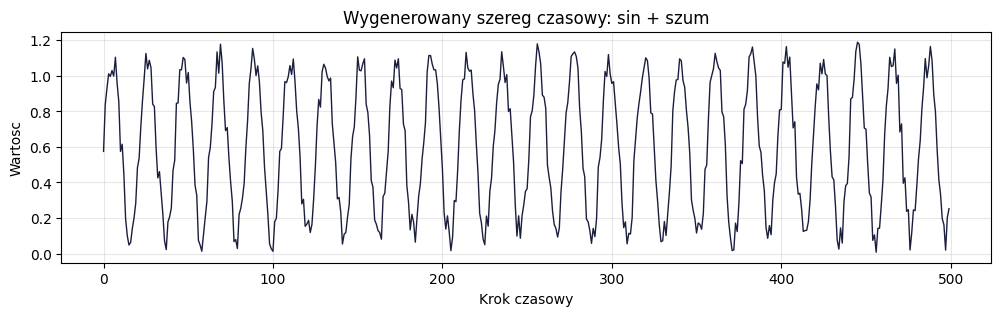

Dlugosc szeregu: 500
Zakres: [0.007, 1.189]


In [12]:
# Krok 1: Generujemy szereg czasowy
np.random.seed(42)
N = 500
t = np.arange(N)
signal = np.sin(t * 0.3) * 0.5 + 0.5 + np.random.rand(N) * 0.2

plt.figure(figsize=(12, 3))
plt.plot(t, signal, color='#1B1E3D', linewidth=1)
plt.title("Wygenerowany szereg czasowy: sin + szum")
plt.xlabel("Krok czasowy")
plt.ylabel("Wartosc")
plt.grid(alpha=0.3)
plt.show()

print(f"Dlugosc szeregu: {N}")
print(f"Zakres: [{signal.min():.3f}, {signal.max():.3f}]")

In [13]:
# Krok 2: Sekwencje (X) i targety (y) z look_back
look_back = 20

X, y = [], []
for i in range(look_back, len(signal)):
    X.append(signal[i - look_back:i])
    y.append(signal[i])

X = np.array(X).reshape(-1, look_back, 1)  # (samples, timesteps, features)
y = np.array(y)

print(f"X shape: {X.shape}  (n_sequences, look_back, n_features)")
print(f"y shape: {y.shape}")

# Podzial train/test (70/30 -- jak w PDF rysunku)
split = int(0.7 * len(X))
X_train, X_test = X[:split], X[split:]
y_train, y_test = y[:split], y[split:]
print(f"\nTrain: {X_train.shape[0]} sekwencji")
print(f"Test:  {X_test.shape[0]} sekwencji")

X shape: (480, 20, 1)  (n_sequences, look_back, n_features)
y shape: (480,)

Train: 336 sekwencji
Test:  144 sekwencji


In [14]:
# Krok 3: Model LSTM
from tensorflow.keras.layers import LSTM, Dropout, Dense

tf.random.set_seed(42)
model_lstm = keras.Sequential([
    LSTM(8, input_shape=(look_back, 1)),
    Dense(1)
])
model_lstm.compile(optimizer='adam', loss='mean_squared_error')
model_lstm.summary()

/Users/macbook/miniconda3/lib/python3.12/site-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential_6"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm (LSTM)                     │ (None, 8)              │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_12 (Dense)                │ (None, 1)              │             9 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 329 (1.29 KB)

 Trainable params: 329 (1.29 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/20
21/21 - 1s - 40ms/step - loss: 0.3830 - val_loss: 0.2937
Epoch 2/20
21/21 - 0s - 4ms/step - loss: 0.2100 - val_loss: 0.1556
Epoch 3/20
21/21 - 0s - 5ms/step - loss: 0.1225 - val_loss: 0.1159
Epoch 4/20
21/21 - 0s - 4ms/step - loss: 0.1058 - val_loss: 0.1082
Epoch 5/20
21/21 - 0s - 3ms/step - loss: 0.0979 - val_loss: 0.1011
Epoch 6/20
21/21 - 0s - 3ms/step - loss: 0.0915 - val_loss: 0.0943
Epoch 7/20
21/21 - 0s - 4ms/step - loss: 0.0853 - val_loss: 0.0877
Epoch 8/20
21/21 - 0s - 3ms/step - loss: 0.0791 - val_loss: 0.0812
Epoch 9/20
21/21 - 0s - 4ms/step - loss: 0.0730 - val_loss: 0.0747
Epoch 10/20
21/21 - 0s - 3ms/step - loss: 0.0668 - val_loss: 0.0680
Epoch 11/20
21/21 - 0s - 3ms/step - loss: 0.0604 - val_loss: 0.0610
Epoch 12/20
21/21 - 0s - 4ms/step - loss: 0.0537 - val_loss: 0.0536
Epoch 13/20
21/21 - 0s - 5ms/step - loss: 0.0465 - val_loss: 0.0458
Epoch 14/20
21/21 - 0s - 4ms/step - loss: 0.0389 - val_loss: 0.0374
Epoch 15/20
21/21 - 0s - 3ms/step - loss: 0.0309 - val_l

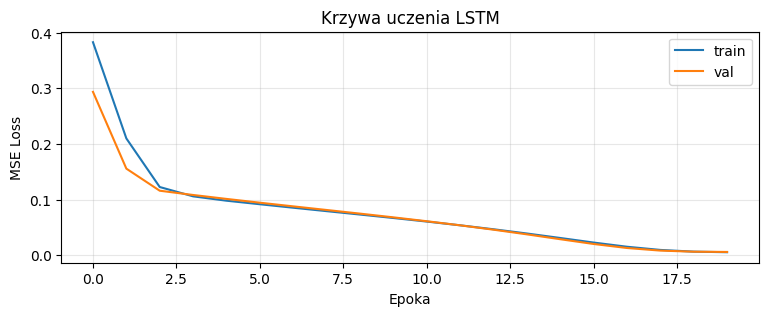

In [15]:
# Krok 4: Trening
history_lstm = model_lstm.fit(
    X_train, y_train,
    epochs=20, batch_size=16,
    validation_data=(X_test, y_test),
    verbose=2
)

# Wykres loss
plt.figure(figsize=(9, 3))
plt.plot(history_lstm.history['loss'], label='train')
plt.plot(history_lstm.history['val_loss'], label='val')
plt.xlabel('Epoka')
plt.ylabel('MSE Loss')
plt.title('Krzywa uczenia LSTM')
plt.legend()
plt.grid(alpha=0.3)
plt.show()

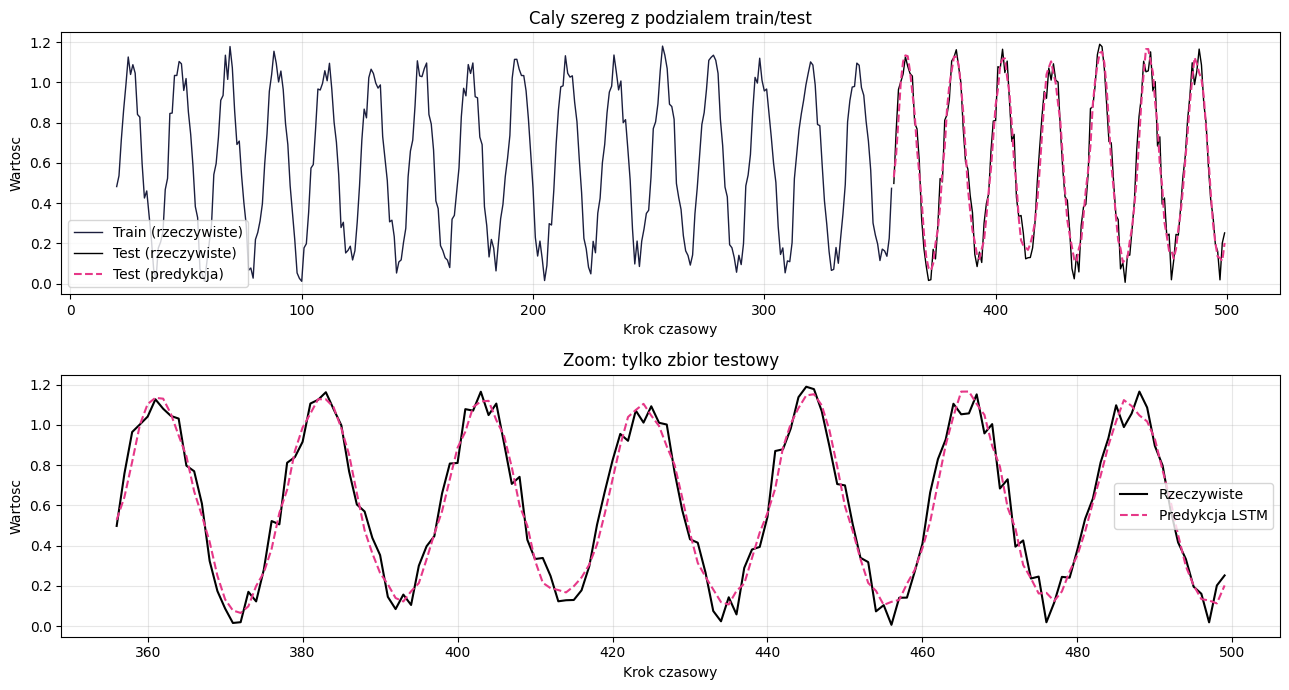


Test MSE: 0.005716
LSTM nauczyl sie rytmu sinusoidy mimo szumu.


In [16]:
# Krok 5: Predykcje
pred_test = model_lstm.predict(X_test, verbose=0).flatten()

fig, axes = plt.subplots(2, 1, figsize=(13, 7))

# Caly szereg z podzialem train/test
x_train_idx = np.arange(look_back, look_back + len(y_train))
x_test_idx = np.arange(look_back + len(y_train), look_back + len(y_train) + len(y_test))

axes[0].plot(x_train_idx, y_train, color='#1B1E3D', label='Train (rzeczywiste)', linewidth=1)
axes[0].plot(x_test_idx, y_test, color='black', label='Test (rzeczywiste)', linewidth=1)
axes[0].plot(x_test_idx, pred_test, color='#E63888', linestyle='--', label='Test (predykcja)', linewidth=1.5)
axes[0].set_title('Caly szereg z podzialem train/test')
axes[0].set_xlabel('Krok czasowy')
axes[0].set_ylabel('Wartosc')
axes[0].legend()
axes[0].grid(alpha=0.3)

# Zoom na test
axes[1].plot(x_test_idx, y_test, color='black', label='Rzeczywiste', linewidth=1.5)
axes[1].plot(x_test_idx, pred_test, color='#E63888', linestyle='--', label='Predykcja LSTM', linewidth=1.5)
axes[1].set_title('Zoom: tylko zbior testowy')
axes[1].set_xlabel('Krok czasowy')
axes[1].set_ylabel('Wartosc')
axes[1].legend()
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.show()

mse_test = ((y_test - pred_test) ** 2).mean()
print(f"\nTest MSE: {mse_test:.6f}")
print("LSTM nauczyl sie rytmu sinusoidy mimo szumu.")

---

# CZĘŚĆ 3 — Zadania do samodzielnego wykonania

## Zadanie A (Lab 5) — CIFAR-10 z optymalizacją augmentacji

Rozszerz powyższy mini-Random Search do **pełnego pipeline'u**:

1. Użyj **wszystkich 10 klas CIFAR-10** (lub minimum 5)
2. Dodaj do search_space: `height_shift_range`, `brightness_range`
3. **K-Fold cross-validation** (k=3 lub k=5) jako kryterium oceny
4. Min **10 prób** Random Search
5. Końcowy trening z najlepszą konfiguracją na pełnym datasecie
6. Ewaluacja na zbiorze testowym

**Bonus:** użyj `optuna` lub `hyperopt` zamiast Random Search.

In [17]:
# TODO Zadanie A: KFold + Random Search
# from sklearn.model_selection import KFold
# 
# kf = KFold(n_splits=3, shuffle=True, random_state=42)
# 
# def evaluate_config(config, X, Y, epochs=8):
#     scores = []
#     for fold_idx, (train_idx, val_idx) in enumerate(kf.split(X)):
#         datagen = ImageDataGenerator(**config)
#         model = cnn_model()
#         hist = model.fit(
#             datagen.flow(X[train_idx], Y[train_idx], batch_size=64),
#             epochs=epochs, validation_data=(X[val_idx], Y[val_idx]), verbose=0
#         )
#         scores.append(hist.history['val_accuracy'][-1])
#     return np.mean(scores)
# 
# # ... petla Random Search ...

# Twoj kod tutaj:


## Zadanie B (Lab 6) — predykcja PM-10 dla Krakowa

Z PDF: *"Na podstawie danych Głównego Inspektoratu Środowiska ze stacji pomiarowej Kraków, ul. Złoty Róg, opracuj model do przewidywania stężenia pyłów zawieszonych PM-10. Przeprowadź badania różnych architektur modeli sekwencyjnych."*

**Plan:**
1. Wczytaj dane (CSV z Teams) — kolumna z wartościami PM-10
2. Wyczyść (NaN), znormalizuj (`MinMaxScaler` 0-1)
3. Stwórz sekwencje: look_back=24 (1 dzień przy danych godzinowych) lub look_back=7 (1 tydzień przy dziennych)
4. Podział train/test (80/20)
5. **Trzy modele do porównania:**
   - SimpleRNN (vanilla)
   - LSTM
   - GRU
6. Wykres porównawczy: real vs predicted dla każdego modelu
7. **Wniosek:** który model najlepszy i dlaczego?

In [18]:
# TODO Zadanie B: PM-10 prediction
# import pandas as pd
# from sklearn.preprocessing import MinMaxScaler
# from tensorflow.keras.layers import SimpleRNN, LSTM, GRU
# 
# # 1. Wczytaj dane
# df = pd.read_csv('PM10_kierunkowo.csv', sep=';', encoding='ISO-8859-1')
# # ... preprocessing ...
# 
# # 2. Sekwencje
# look_back = 24
# X, y = [], []
# for i in range(look_back, len(scaled)):
#     X.append(scaled[i-look_back:i, 0])
#     y.append(scaled[i, 0])
# 
# # 3. Porownanie 3 modeli
# models = {
#     'SimpleRNN': keras.Sequential([SimpleRNN(32, input_shape=(look_back, 1)), Dense(1)]),
#     'LSTM':      keras.Sequential([LSTM(32, input_shape=(look_back, 1)), Dense(1)]),
#     'GRU':       keras.Sequential([GRU(32, input_shape=(look_back, 1)), Dense(1)]),
# }
# 
# # Trenuj kazdy, porownaj wyniki

# Twoj kod tutaj:


---

## Sprawdź, co umiesz — pytania kontrolne

**Część Lab 5:**
1. **Po co augmentacja danych?** (3 korzyści)
2. **Czym różni się on-the-fly od pre-processing augmentacji?**
3. **Jakie są 3 grupy technik augmentacji?**
4. **Co robi `ImageDataGenerator.flow()`?**
5. **Co znaczy overfitting i jak augmentacja temu zapobiega?**

**Część Lab 6:**
6. **Dlaczego CNN nie nadaje się do szeregów czasowych?**
7. **Co to jest stan ukryty $a_t$ w RNN?**
8. **Wymień 3 typy struktur RNN i ich zastosowania.**
9. **Co to vanishing gradient i jak LSTM go rozwiązuje?**
10. **Jakie są 3 bramki w LSTM i co każda robi?**

---

## Jedno zdanie do zapamiętania

> **Augmentacja to sztuczne tworzenie wariacji obrazów, żeby CNN nauczyła się generalizować. RNN/LSTM to sieci z pętlą rekurencyjną, które pamiętają kontekst — używamy ich do sekwencji (tekst, szeregi czasowe, audio). LSTM rozwiązuje vanishing gradient przez bramki kontrolujące przepływ pamięci.**

## Co dalej?

- **Transformery** — wyparły LSTM w NLP (Attention is All You Need)
- **CNN+RNN combo** — np. video classification
- **Transfer learning** — pretrenowane modele (ResNet, EfficientNet) zamiast trenowania od zera
- **Augmentacja audio/tekstu** — SpecAugment, back-translation